# 02 구간·신뢰도 보정

목적: 기준선(01)의 80% 구간은 실제 거래가를 60~65%만 담았고(너무 좁음), 신뢰도는 근거 수준만으로 정해 값이 0.65·0.80 두 개에 몰렸다.
블라인드 평가는 **신뢰도와 실제 오차가 맞는지**를 보므로, 구간과 신뢰도를 **검증 오차로 다시 정한다.** 설계와 판단은 `docs/의사결정/1007_09_구간_신뢰도_보정.md`.

추정값은 최종 모델(B1 + XGBoost 보정, `docs/의사결정/1007_10_ML_비교.md`)이다. 보정 표본·최종 검증 모두 폴드·상황마다 같은 학습 세트로 최종 모델을 다시 맞춰 추정한다.

| 단계 | 방법 |
|---|---|
| 보정 표본 | 최종 검증 건물 632개는 거래까지 모두 빼고, 나머지 후보 2,527개를 5개 폴드로 나눠 폴드마다 검증 건물처럼 추정(A·B 상황 × 면적 있음·비움 → 약 1만 건). `src/build_calibration.py` |
| 오차 점수 | \|log 오차\|를 예측 시점에 아는 변수(구, 면적, 같은 건물 근거·거래 수, 비율의 흩어짐, 면적 추정 여부, XGBoost 두 모델의 차이·B1에서 옮겨 간 정도)로 최소제곱 회귀 |
| 구간 | 점수 10분위마다 log 오차의 10%·90% 분위수 |
| 신뢰도 | 점수 10분위마다 **±20% 적중률**(점수가 클수록 낮아지게 단조 보정) = "검증에서 비슷한 조건의 추정이 실거래가 ±20% 안에 든 비율" |
| 평가 | 보정에 쓰지 않은 최종 검증 건물 632개(01과 같은 분할) |


In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from avm import load_refs, run_holdout, evaluate, Calibrator, ERR_FEATURES, SGG_NAME, PROC
plt.rcParams["font.family"] = "Malgun Gothic"; plt.rcParams["axes.unicode_minus"] = False
OUT = ROOT / "outputs"
cal = Calibrator.load()
calib = pd.read_csv(OUT / "calibration_preds.csv", dtype={"pnu": str, "sgg_cd": str})
print(f"보정 표본 {len(calib):,}건, 공시비율 {(calib.method == '공시비율').sum():,}건")

보정 표본 10,108건, 공시비율 10,088건


## 1. 오차 점수 회귀 계수

|log 오차|(대략 오차율)에 더해지는 양. 양수면 오차를 키우는 요인이다.

In [2]:
coef = pd.Series(cal.coef, index=ERR_FEATURES, name="계수")
desc = {"const": "절편", "gangnam": "강남구(기준 관악)", "hwagok": "강서구 화곡동(기준 관악)", "log_area": "log 전용면적",
        "same": "같은 건물 거래가 근거", "log_n": "log(1+같은 건물 거래 수)", "b_sd": "같은 건물 비율의 흩어짐",
        "b_gap": "같은 건물 비율과 동네 비율의 차이", "area_sd": "동네(법정동·구) 비율의 흩어짐", "area_blank": "면적 비어 추정",
        "ml_gap": "XGBoost 직접·잔차 추정의 차이(|log|)", "ml_shift": "ML 보정 배율(|log|, B1에서 옮겨 간 정도)"}
pd.DataFrame({"뜻": desc, "계수": coef.round(4)})

,뜻,계수
const,절편,0.2528
gangnam,강남구(기준 관악),0.0218
hwagok,강서구 화곡동(기준 관악),0.0195
log_area,log 전용면적,-0.0457
same,같은 건물 거래가 근거,-0.0046
log_n,log(1+같은 건물 거래 수),-0.0189
b_sd,같은 건물 비율의 흩어짐,0.0221
b_gap,같은 건물 비율과 동네 비율의 차이,0.0428
area_sd,동네(법정동·구) 비율의 흩어짐,0.2678
area_blank,면적 비어 추정,0.0116


## 2. 보정표 (보정 표본, 교차 적합 점수 10분위)

In [3]:
tab = pd.read_csv(OUT / "calibration_table.csv")
tab.style.format({"점수_상한": "{:.3f}", "중앙값APE": "{:.1%}", "±20%적중률": "{:.1%}", "신뢰도": "{:.2f}", "log오차_q10": "{:.3f}", "log오차_q90": "{:.3f}"})

,점수_상한,n,중앙값APE,±20%적중률,신뢰도,log오차_q10,log오차_q90
0,0.114,1009,7.3%,85.6%,0.86,-0.160,0.175
1,0.125,1009,9.0%,82.3%,0.82,-0.182,0.190
2,0.134,1009,9.8%,80.0%,0.80,-0.199,0.197
3,0.142,1008,9.9%,78.5%,0.78,-0.210,0.211
4,0.151,1009,10.2%,77.4%,0.77,-0.216,0.225
5,0.159,1009,11.0%,72.4%,0.72,-0.260,0.234
6,0.169,1008,12.3%,68.8%,0.69,-0.283,0.260
7,0.182,1009,12.8%,66.0%,0.66,-0.277,0.283
8,0.205,1009,14.3%,64.5%,0.65,-0.315,0.277
9,inf,1009,20.4%,49.2%,0.49,-0.459,0.303


## 3. 최종 검증 건물에서 보정 전후

같은 추정값(price_est, 최종 모델)에 구간·신뢰도만 바꾼다. 이전 = 근거 수준 규칙(1007_08), 보정 = 보정표. 면적 비움은 입력 면적을 지워 공시가격 호 면적 등으로 채우는 경우.

In [4]:
refs = load_refs()
test_pnu = pd.read_csv(PROC / "holdout_pnu.csv", dtype=str)["pnu"]
runs = {}
for sc in "AB":
    runs[(sc, "이전")] = run_holdout(refs, sc, test_pnu=test_pnu, area_blank=(False, True), ml=True)
    runs[(sc, "보정")] = run_holdout(refs, sc, test_pnu=test_pnu, area_blank=(False, True), calibrator=cal, ml=True)
def metrics(q):
    m = evaluate(q)
    m["순위상관(신뢰도,APE)"] = q.confidence.rank().corr(q.ape.rank())
    m["신뢰도 값 개수"] = q.confidence.round(2).nunique()
    m["구간폭 중앙값(상한/하한-1)"] = np.median(q.price_high / q.price_low - 1)
    return m
rows = {(sc, name, "비움" if bl else "있음"): metrics(p[p.area_blank == bl]) for (sc, name), p in runs.items() for bl in (False, True)}
met = pd.DataFrame(rows).T; met.index.names = ["상황", "구분", "면적"]
met.to_csv(OUT / "calibration_metrics.csv", encoding="utf-8-sig")
pd.concat({k: v for k, v in runs.items()}, names=["상황", "구분"]).reset_index(level=[0, 1]).drop(columns="flags").to_csv(
    OUT / "calibration_holdout_preds.csv", index=False, encoding="utf-8-sig")
met.style.format({"n": "{:.0f}", "MAPE": "{:.1%}", "중앙값APE": "{:.1%}", "±10%": "{:.1%}", "±20%": "{:.1%}", "80%구간포함률": "{:.1%}",
                  "순위상관(신뢰도,APE)": "{:.3f}", "신뢰도 값 개수": "{:.0f}", "구간폭 중앙값(상한/하한-1)": "{:.1%}"})

## 4. 신뢰도가 정직한가 — 신뢰도 구간별 실제 ±20% 적중률

대각선에 가까울수록 '신뢰도 0.7 = 열에 일곱은 ±20% 안'이 맞는다.

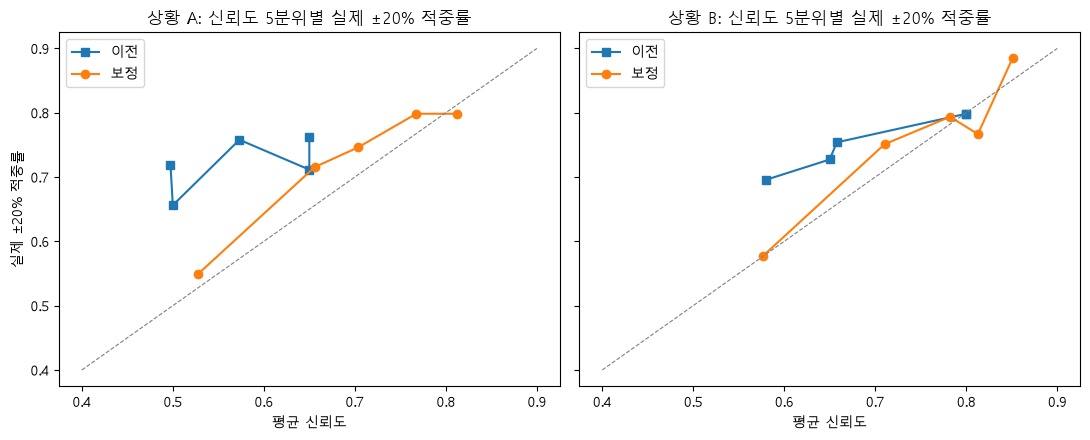

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, sc in zip(axes, "AB"):
    for name, mk in [("이전", "s"), ("보정", "o")]:
        q = runs[(sc, name)]
        g = q.groupby(pd.qcut(q.confidence.rank(method="first"), 5), observed=True)
        r = g.agg(conf=("confidence", "mean"), hit=("ape", lambda v: (v <= 0.2).mean()), n=("ape", "size"))
        ax.plot(r.conf, r.hit, marker=mk, label=name)
    ax.plot([0.4, 0.9], [0.4, 0.9], color="gray", lw=0.8, ls="--")
    ax.set_title(f"상황 {sc}: 신뢰도 5분위별 실제 ±20% 적중률"); ax.set_xlabel("평균 신뢰도"); ax.legend()
axes[0].set_ylabel("실제 ±20% 적중률"); plt.tight_layout(); plt.show()

In [6]:
def by_conf(q):
    inside = (q.actual >= q.price_low) & (q.actual <= q.price_high)
    return q.assign(inside=inside).groupby(pd.cut(q.confidence, [0, 0.6, 0.65, 0.7, 0.75, 1.0]), observed=True).agg(
        n=("ape", "size"), 평균신뢰도=("confidence", "mean"), 실제_20적중률=("ape", lambda v: (v <= 0.2).mean()),
        중앙값APE=("ape", "median"), 구간포함률=("inside", "mean"))
for sc in "AB":
    print(f"상황 {sc} (보정, 면적 있음·비움 합산)")
    display(by_conf(runs[(sc, "보정")]).style.format({"평균신뢰도": "{:.2f}", "실제_20적중률": "{:.1%}", "중앙값APE": "{:.1%}", "구간포함률": "{:.1%}"}))

상황 A (보정, 면적 있음·비움 합산)


,n,평균신뢰도,실제_20적중률,중앙값APE,구간포함률
confidence,,,,,
"(0.0, 0.6]",183,0.48,48.6%,20.7%,80.3%
"(0.6, 0.65]",155,0.65,67.7%,13.0%,85.2%
"(0.65, 0.7]",315,0.67,76.2%,9.8%,87.6%
"(0.7, 0.75]",153,0.72,71.9%,10.9%,78.4%
"(0.75, 1.0]",458,0.80,80.3%,8.7%,79.7%


상황 B (보정, 면적 있음·비움 합산)


,n,평균신뢰도,실제_20적중률,중앙값APE,구간포함률
confidence,,,,,
"(0.0, 0.6]",108,0.48,50.9%,19.7%,82.4%
"(0.6, 0.65]",93,0.65,61.3%,16.2%,77.4%
"(0.65, 0.7]",170,0.67,67.1%,11.9%,80.6%
"(0.7, 0.75]",103,0.72,78.6%,9.9%,87.4%
"(0.75, 1.0]",790,0.81,81.9%,8.7%,78.9%


## 5. 권역별 (보정, 상황 B, 면적 있음)

In [7]:
q = runs[("B", "보정")]; q = q[~q.area_blank].assign(권역=lambda d: d.sgg_cd.map(SGG_NAME))
inside = (q.actual >= q.price_low) & (q.actual <= q.price_high)
q.assign(inside=inside).groupby("권역").agg(n=("ape", "size"), 평균신뢰도=("confidence", "mean"),
    실제_20적중률=("ape", lambda v: (v <= 0.2).mean()), 중앙값APE=("ape", "median"), 구간포함률=("inside", "mean")).round(3)

,n,평균신뢰도,실제_20적중률,중앙값APE,구간포함률
권역,,,,,
강남구,133,0.684,0.722,0.127,0.820
강서구,262,0.780,0.805,0.085,0.798
관악구,237,0.778,0.789,0.094,0.814


## 6. 관찰

결과 수치는 위 표에서 읽고, 해석·한계는 `docs/의사결정/1007_09_구간_신뢰도_보정.md`에 정리한다.